# `errorgnomark` Modularity Deep Dive: A Hands-On Guide to the Benchmarking Module

## 1. Document Purpose

`errorgnomark` is a highly modular Python library designed for quantum error characterization. While it provides complete end-to-end experimental workflows (e.g., `run_and_fit`), its true power lies in the fact that each component of the workflow—**circuit generation**, **backend execution**, and **data analysis**—can be decoupled and used independently.

This tutorial focuses on the benchmarking module of `errorgnomark`. Through three distinct examples, it will demonstrate how to leverage its modularity to meet custom requirements:

1.  **Standalone Benchmark Circuit Generation**: For when you only need one or more Randomized Benchmarking (RB) circuits without immediate execution.
2.  **Integration with Custom Circuit Formats**: How to convert circuits generated by `errorgnomark` into your own proprietary quantum circuit representation.
3.  **Standalone Analysis of External Data**: How to use only `errorgnomark`'s analysis and plotting tools to process experimental data you have already collected on your own quantum hardware or simulator.

**Please Note**: This tutorial is intended to showcase modular usage. For complete, end-to-end experimental development workflows, please refer to the documentation in the official `tutorials/` directory.

---

## 2. Standalone Benchmark Circuit Generation

In many scenarios, you may only want to generate a quantum circuit for a specific benchmarking protocol (like Standard RB) for other purposes, such as running it in a custom simulator or for theoretical analysis. `errorgnomark` makes this easy.

We will demonstrate this by generating a single, standard 2-qubit RB circuit with a Clifford sequence depth of 10.

### Implementation Steps

We can directly instantiate `errorgnomark`'s internal `_RBEngine` class, which is the core engine responsible for generating RB circuits.

In [6]:
# Import relevant internal modules and classes.
# Note: Directly calling internal modules (prefixed with an underscore)
# is an advanced usage pattern intended for maximum flexibility.
from errorgnomark.experiments.benchmarking.rb import _RBEngine
from errorgnomark.experiments.gate_sets import get_gate_set
# --- [NEW ADDITION 1] ---
# Import the visualization function you provided.
from errorgnomark.circuits.visualization import format_circuit_as_string

# 1. Define experimental parameters
qubits = [0, 1]
depth = 10  # The desired Clifford sequence depth
circuits_per_depth = 1 # We only need to generate one circuit
gate_set = get_gate_set('clifford') 

# 2. Instantiate the RB engine
# _RBEngine handles all logic related to RB circuit generation.
rb_engine = _RBEngine(
    qubits=qubits,
    depths=[depth],  # The engine expects a list of depths
    circuits_per_depth=circuits_per_depth,
    gate_set=gate_set
)

# 3. Call the internal method to generate a single circuit
# _generate_single_circuit returns a QuantumCircuit object.
print(f"--- Generating a standard RB circuit with depth {depth} ---")
single_rb_circuit = rb_engine._generate_single_circuit(depth)

# --- [NEW ADDITION 2] ---
# Use the new function to draw the circuit.
# This replaces the previous `print(single_rb_circuit)` and the gate loop.
print("\n--- Formatted Circuit Diagram ---")
formatted_circuit_string = format_circuit_as_string(single_rb_circuit)
print(formatted_circuit_string)

--- Generating a standard RB circuit with depth 10 ---

--- Formatted Circuit Diagram ---
q0: [X]---●----[Z]---●----[X]---●----[Z]---●----[S]---●----[X]---●----[Z]---●----[H]---●----[X]---●----[Z]---●------●----[Z]---●----[X]---●----[H]---●----[Z]---●----[X]---●----[Sdg]---●----[Z]---●----[X]---●----[Z]---●-----[X]--
q1: [S]-[CNOT]-[Y]-[CNOT]-[H]-[CNOT]-[H]-[CNOT]-[S]-[CNOT]-[H]-[CNOT]-[H]-[CNOT]-[X]-[CNOT]-[Y]-[CNOT]-[X]-[CNOT]-[CNOT]-[X]-[CNOT]-[Y]-[CNOT]-[X]-[CNOT]-[H]-[CNOT]-[H]-[CNOT]-[Sdg]-[CNOT]-[H]-[CNOT]-[H]-[CNOT]-[Y]-[CNOT]-[Sdg]-


---

## 3. Integrating Custom Circuit Formats

`errorgnomark`'s `QuantumCircuit` and `Gate` objects are self-contained and structured. This high degree of interoperability means you can easily iterate through a generated circuit and convert it into any custom format you require.

Let's assume you have a proprietary format named `SISQ` (Simple Instruction Set for Quantum), where instructions are represented as strings like `"GATE_NAME QUBIT_1 QUBIT_2 ..."`. We can write a simple `egm_to_sisq_converter` to perform this translation.

### Implementation Steps

We will reuse the `single_rb_circuit` object generated in the previous cell and convert it to the `SISQ` format.

In [9]:
# This code assumes `single_rb_circuit` has been generated from the code in CELL 3.
# We also need the QuantumCircuit class for type checking.
from errorgnomark.circuits.circuit import QuantumCircuit

def egm_to_sisq_converter(egm_circuit: QuantumCircuit) -> list[str]:
    """
    An improved converter that translates an errorgnomark QuantumCircuit object
    into a custom, more representative "SISQ" format.

    This version includes:
    1. Input type validation.
    2. Strict error handling for unknown gates.
    3. Special formatting for multi-qubit gates (like CNOT).
    
    Args:
        egm_circuit (QuantumCircuit): The errorgnomark circuit object.
        
    Returns:
        list[str]: A list of strings, where each string is an instruction
                   in the SISQ format.
                   
    Raises:
        TypeError: If the input is not a QuantumCircuit object.
        KeyError: If the circuit contains a gate not defined in gate_name_map.
    """
    # [MODIFICATION 1: Add input validation]
    # Ensure we are handling the correct object type, which is good programming practice.
    if not isinstance(egm_circuit, QuantumCircuit):
        raise TypeError(f"Input must be a QuantumCircuit object, but got {type(egm_circuit)}.")

    print("...Starting conversion with the robust converter...")
    sisq_instructions = []
    
    # A flexible mapping from errorgnomark gate names to SISQ names
    gate_name_map = {
        'CNOT': 'CX',
        'H': 'H',
        'S': 'S',
        'X': 'X',
        'Y': 'Y',
        'Z': 'Z',
        'Sdg': 'SDG',
        # ... more custom mappings can be added here as needed ...
    }
    
    # Iterate over each gate object in the circuit
    for gate in egm_circuit.gates:
        # [MODIFICATION 2: Stricter gate name handling]
        # If the gate is not in the map, raise an error directly instead of guessing a default name.
        # This prevents silent failures due to unknown gates.
        if gate.name not in gate_name_map:
            raise KeyError(f"Gate '{gate.name}' is not defined in the conversion map. "
                           "Please add it to `gate_name_map`.")
        
        sisq_gate_name = gate_name_map[gate.name]
        
        # [MODIFICATION 3: Special handling for multi-qubit gates]
        # Different gates may have different formatting requirements.
        if len(gate.qubits) == 1:
            # Single-qubit gate format: e.g., "H 0"
            instruction = f"{sisq_gate_name} {gate.qubits[0]}"
        elif gate.name == 'CNOT':
            # Special format for CNOT gate: e.g., "CX 0 1" (control qubit first)
            control_qubit = gate.qubits[0]
            target_qubit = gate.qubits[1]
            instruction = f"{sisq_gate_name} {control_qubit} {target_qubit}"
        else:
            # Provide a generic fallback for other (future) multi-qubit gates
            qubit_indices = ' '.join(map(str, gate.qubits))
            instruction = f"{sisq_gate_name} {qubit_indices}"
            
        sisq_instructions.append(instruction)
        
    print("...Conversion complete.")
    return sisq_instructions

# Use the converter
print("\n--- Converting EGM Circuit to SISQ Format ---")
try:
    sisq_program = egm_to_sisq_converter(single_rb_circuit)

    # Print the first 10 instructions of the resulting SISQ program
    print("\n--- Resulting SISQ Program (first 10 instructions) ---")
    for instruction in sisq_program[:10]:
        print(instruction)
except (TypeError, KeyError) as e:
    print(f"\n--- Conversion Failed ---")
    print(f"An error occurred during conversion: {e}")


--- Converting EGM Circuit to SISQ Format ---
...Starting conversion with the robust converter...
...Conversion complete.

--- Resulting SISQ Program (first 10 instructions) ---
X 0
S 1
CX 0 1
Z 0
Y 1
CX 0 1
X 0
H 1
CX 0 1
Z 0


---

## 4. Standalone Analysis of External Data

Perhaps the most powerful modular feature is the ability to use `errorgnomark`'s analysis engine on data you've collected elsewhere. If you have already run RB experiments on your hardware and have the survival probability data, you don't need to re-run anything. You can directly feed your data into the analysis functions to get fitted parameters (like EPC) and publication-quality plots.

### Implementation Steps

We will simulate a scenario where we have pre-existing survival probability data for both a Standard RB and an Interleaved RB experiment. We will then use `errorgnomark`'s fitting and plotting functions to analyze this data.

--- Preparing mock external data... ---
--- Data prepared. Starting standalone analysis using the errorgnomark library. ---

--- Fitting Standard RB data... ---
Standard EPC = 1.430e-02

--- Fitting Interleaved RB data... ---
Interleaved EPC = 3.917e-02

--- Calculating gate error... ---
Calculated Error of 'CNOT' gate (r_G) = 1.866e-02

--- Generating comparison plot... ---


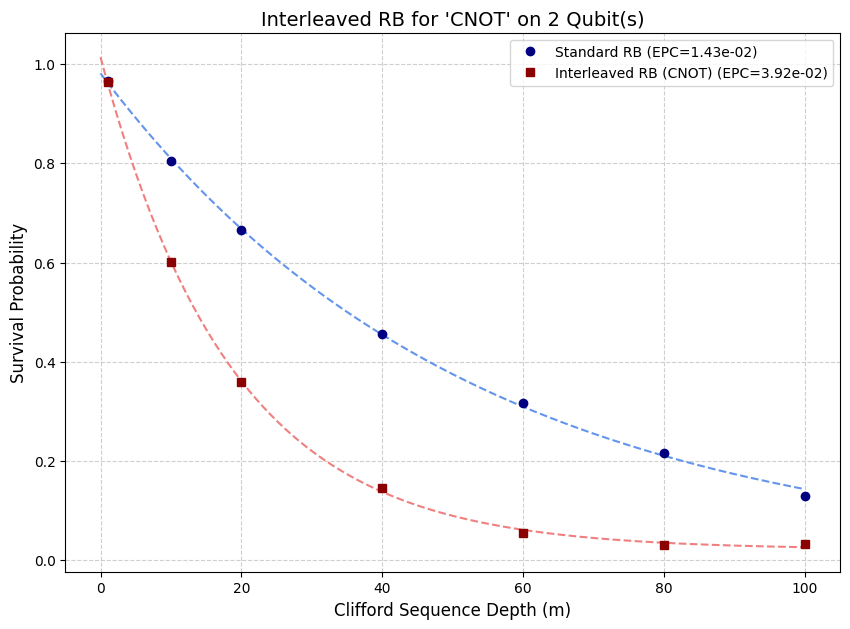


--- Analysis complete. Plot window should be displayed. ---


In [10]:
# ---------------------------------------------------------------------------
# Standalone Analysis Script for a User of the 'errorgnomark' Library
#
# PRE-REQUISITE: This script assumes the 'errorgnomark' library has been
# installed in the Python environment (e.g., via `pip install .` in the
# library's root directory).
# ---------------------------------------------------------------------------

import numpy as np
# [MODIFICATION] Import the necessary, pre-defined functions directly from your library.
# The function definitions are no longer repeated in this script.
from errorgnomark.analysis.benchmarking.rb_analysis import fit_rb_data, plot_rb_comparison

# 1. Define the experimental parameters
num_qubits = 2
depths = [1, 10, 20, 40, 60, 80, 100]
target_gate_name = 'CNOT'
circuits_per_depth = 15

# 2. Prepare mock external data (e.g., from a hardware run or another simulator)
# The data is structured as a dictionary {depth: [survival_probs]}, which is
# exactly what the `fit_rb_data` function expects.
print("--- Preparing mock external data... ---")
A_true, B_true = 0.99, 0.01
p_std_true, p_int_true = 0.98, 0.95 # True decay parameters for simulation

noise = lambda: np.random.normal(0, 0.03)

mock_std_survivals_dict = {
    m: [A_true * (p_std_true**m) + B_true + noise() for _ in range(circuits_per_depth)]
    for m in depths
}
mock_int_survivals_dict = {
    m: [A_true * (p_int_true**m) + B_true + noise() for _ in range(circuits_per_depth)]
    for m in depths
}
print("--- Data prepared. Starting standalone analysis using the errorgnomark library. ---")


# 3. [Module 1: Fitting] Analyze the Standard RB data by calling the library function
print("\n--- Fitting Standard RB data... ---")
results_std = fit_rb_data(mock_std_survivals_dict, num_qubits)
if results_std['fit_successful']:
    print(f"Standard EPC = {results_std['epc']:.3e}")
else:
    print("Standard RB fit failed.")


# 4. [Module 1: Fitting] Analyze the Interleaved RB data by calling the library function
print("\n--- Fitting Interleaved RB data... ---")
results_int = fit_rb_data(mock_int_survivals_dict, num_qubits)
if results_int['fit_successful']:
    print(f"Interleaved EPC = {results_int['epc']:.3e}")
else:
    print("Interleaved RB fit failed.")


# 5. [Module 2: Calculation] Calculate the target gate error using the fit results
print("\n--- Calculating gate error... ---")
gate_error = -1.0
if results_std['fit_successful'] and results_int['fit_successful']:
    d = 2**num_qubits
    epc_std = results_std['epc']
    epc_int = results_int['epc']
    # This formula is the standard way to derive gate error from EPC values
    gate_error = (d - 1) * (epc_int - epc_std) / d
    print(f"Calculated Error of '{target_gate_name}' gate (r_G) = {gate_error:.3e}")
else:
    print("Could not calculate gate error because one or both fits failed.")


# 6. [Module 3: Plotting] Generate the final comparison plot by calling the library function
print("\n--- Generating comparison plot... ---")
plot_rb_comparison(
    results_std=results_std,
    results_int=results_int,
    num_qubits=num_qubits,
    target_gate_name=target_gate_name
)

print("\n--- Analysis complete. Plot window should be displayed. ---")